# Retail Demand Forecasting & Sales Planning

## Item-Level Forecasting using M5 Walmart Dataset

This notebook builds an item-level demand forecasting pipeline using the M5 Walmart dataset.

The goal is to forecast the next 28 days of sales demand for selected high-selling items in store CA_1.

Item-level forecasting is more difficult than category, department, or store-level forecasting because individual items often have sparse, noisy, and irregular demand.

To keep the first item-level version efficient and meaningful, we focus on the top-selling items in store CA_1.

In [2]:
import os
import sys
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Python executable:")
print(sys.executable)

BASE_DIR = os.path.abspath("..")

RAW_DATA_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
MODELS_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Raw data directory:", RAW_DATA_DIR)

Python executable:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\.venv\Scripts\python.exe
Base directory: c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting
Raw data directory: c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\raw


In [3]:
calendar_path = os.path.join(RAW_DATA_DIR, "calendar.csv")
sales_path = os.path.join(RAW_DATA_DIR, "sales_train_validation.csv")
prices_path = os.path.join(RAW_DATA_DIR, "sell_prices.csv")

calendar_df = pd.read_csv(calendar_path)
sales_df = pd.read_csv(sales_path)
prices_df = pd.read_csv(prices_path)

print("Calendar shape:", calendar_df.shape)
print("Sales shape:", sales_df.shape)
print("Prices shape:", prices_df.shape)

Calendar shape: (1969, 14)
Sales shape: (30490, 1919)
Prices shape: (6841121, 4)


In [4]:
SELECTED_STORE = "CA_1"

store_sales_df = sales_df[
    sales_df["store_id"] == SELECTED_STORE
].copy()

print("Selected store:", SELECTED_STORE)
print("Store sales shape:", store_sales_df.shape)

store_sales_df.head()

Selected store: CA_1
Store sales shape: (3049, 1919)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,...,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,3,0,0,0,1,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,2,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,...,5,3,1,0,0,0,1,2,3,0,1,3,4,2,1,4,1,3,5,0,6,6,0,0,0,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,2,1,1,0,3,1,1,2,1,1,0,3,2,2,2,3,1,0,0,0,0,1,0,4,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4


In [5]:
day_columns = [col for col in store_sales_df.columns if col.startswith("d_")]

print("Number of day columns:", len(day_columns))
print("First 5 day columns:", day_columns[:5])
print("Last 5 day columns:", day_columns[-5:])

Number of day columns: 1913
First 5 day columns: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last 5 day columns: ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [6]:
store_sales_df["total_sales"] = store_sales_df[day_columns].sum(axis=1)

top_items_df = (
    store_sales_df[
        ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id", "total_sales"]
    ]
    .sort_values("total_sales", ascending=False)
    .reset_index(drop=True)
)

top_items_df.head(20)

,id,item_id,dept_id,cat_id,store_id,state_id,total_sales
0,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,127203
1,FOODS_3_586_CA_1_validation,FOODS_3_586,FOODS_3,FOODS,CA_1,CA,87691
2,FOODS_3_252_CA_1_validation,FOODS_3_252,FOODS_3,FOODS,CA_1,CA,74971
3,FOODS_3_120_CA_1_validation,FOODS_3_120,FOODS_3,FOODS,CA_1,CA,61899
4,FOODS_3_714_CA_1_validation,FOODS_3_714,FOODS_3,FOODS,CA_1,CA,54080
5,FOODS_3_587_CA_1_validation,FOODS_3_587,FOODS_3,FOODS,CA_1,CA,51717
6,FOODS_3_808_CA_1_validation,FOODS_3_808,FOODS_3,FOODS,CA_1,CA,46094
7,FOODS_2_197_CA_1_validation,FOODS_2_197,FOODS_2,FOODS,CA_1,CA,40698
8,FOODS_3_080_CA_1_validation,FOODS_3_080,FOODS_3,FOODS,CA_1,CA,39145
9,FOODS_3_555_CA_1_validation,FOODS_3_555,FOODS_3,FOODS,CA_1,CA,37871


In [7]:
TOP_N_ITEMS = 10

selected_items = top_items_df.head(TOP_N_ITEMS)["id"].tolist()

selected_items

['FOODS_3_090_CA_1_validation',
 'FOODS_3_586_CA_1_validation',
 'FOODS_3_252_CA_1_validation',
 'FOODS_3_120_CA_1_validation',
 'FOODS_3_714_CA_1_validation',
 'FOODS_3_587_CA_1_validation',
 'FOODS_3_808_CA_1_validation',
 'FOODS_2_197_CA_1_validation',
 'FOODS_3_080_CA_1_validation',
 'FOODS_3_555_CA_1_validation']

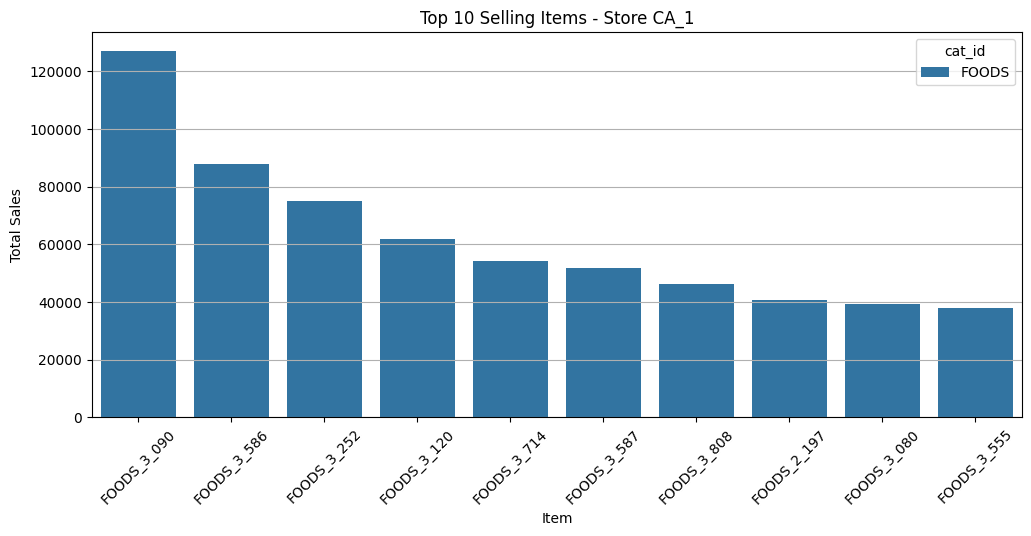

In [8]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=top_items_df.head(TOP_N_ITEMS),
    x="item_id",
    y="total_sales",
    hue="cat_id"
)

plt.title(f"Top {TOP_N_ITEMS} Selling Items - Store {SELECTED_STORE}")
plt.xlabel("Item")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [9]:
selected_store_sales_df = store_sales_df[
    store_sales_df["id"].isin(selected_items)
].copy()

print("Selected item data shape:", selected_store_sales_df.shape)

selected_store_sales_df[
    ["id", "item_id", "dept_id", "cat_id", "store_id", "total_sales"]
]

Selected item data shape: (10, 1920)


,id,item_id,dept_id,cat_id,store_id,total_sales
2023,FOODS_2_197_CA_1_validation,FOODS_2_197,FOODS_2,FOODS,CA_1,40698
2304,FOODS_3_080_CA_1_validation,FOODS_3_080,FOODS_3,FOODS,CA_1,39145
2314,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,127203
2344,FOODS_3_120_CA_1_validation,FOODS_3_120,FOODS_3,FOODS,CA_1,61899
2476,FOODS_3_252_CA_1_validation,FOODS_3_252,FOODS_3,FOODS,CA_1,74971
2779,FOODS_3_555_CA_1_validation,FOODS_3_555,FOODS_3,FOODS,CA_1,37871
2810,FOODS_3_586_CA_1_validation,FOODS_3_586,FOODS_3,FOODS,CA_1,87691
2811,FOODS_3_587_CA_1_validation,FOODS_3_587,FOODS_3,FOODS,CA_1,51717
2937,FOODS_3_714_CA_1_validation,FOODS_3_714,FOODS_3,FOODS,CA_1,54080
3029,FOODS_3_808_CA_1_validation,FOODS_3_808,FOODS_3,FOODS,CA_1,46094


In [10]:
id_columns = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

selected_items_long_df = selected_store_sales_df.melt(
    id_vars=id_columns,
    value_vars=day_columns,
    var_name="d",
    value_name="sales"
)

print("Selected items long shape:", selected_items_long_df.shape)

selected_items_long_df.head()

Selected items long shape: (19130, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,FOODS_2_197_CA_1_validation,FOODS_2_197,FOODS_2,FOODS,CA_1,CA,d_1,38
1,FOODS_3_080_CA_1_validation,FOODS_3_080,FOODS_3,FOODS,CA_1,CA,d_1,33
2,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1,107
3,FOODS_3_120_CA_1_validation,FOODS_3_120,FOODS_3,FOODS,CA_1,CA,d_1,0
4,FOODS_3_252_CA_1_validation,FOODS_3_252,FOODS_3,FOODS,CA_1,CA,d_1,19


In [11]:
selected_items_long_df = selected_items_long_df.merge(
    calendar_df[
        [
            "d",
            "date",
            "wm_yr_wk",
            "weekday",
            "wday",
            "month",
            "year",
            "event_name_1",
            "event_type_1",
            "snap_CA"
        ]
    ],
    on="d",
    how="left"
)

selected_items_long_df["date"] = pd.to_datetime(selected_items_long_df["date"])

print("Shape after calendar merge:", selected_items_long_df.shape)

selected_items_long_df.head()

Shape after calendar merge: (19130, 17)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,snap_CA
0,FOODS_2_197_CA_1_validation,FOODS_2_197,FOODS_2,FOODS,CA_1,CA,d_1,38,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
1,FOODS_3_080_CA_1_validation,FOODS_3_080,FOODS_3,FOODS,CA_1,CA,d_1,33,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
2,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,d_1,107,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
3,FOODS_3_120_CA_1_validation,FOODS_3_120,FOODS_3,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
4,FOODS_3_252_CA_1_validation,FOODS_3_252,FOODS_3,FOODS,CA_1,CA,d_1,19,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0


In [12]:
item_processed_path = os.path.join(
    PROCESSED_DATA_DIR,
    f"top_{TOP_N_ITEMS}_item_daily_sales_{SELECTED_STORE}.csv"
)

selected_items_long_df.to_csv(item_processed_path, index=False)

print("Saved item-level processed data to:")
print(item_processed_path)

Saved item-level processed data to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\processed\top_10_item_daily_sales_CA_1.csv


In [13]:
item_summary_df = (
    selected_items_long_df
    .groupby(["id", "item_id", "dept_id", "cat_id"], as_index=False)
    .agg(
        avg_daily_sales=("sales", "mean"),
        median_daily_sales=("sales", "median"),
        min_daily_sales=("sales", "min"),
        max_daily_sales=("sales", "max"),
        total_sales=("sales", "sum"),
        zero_sales_days=("sales", lambda x: (x == 0).sum())
    )
)

item_summary_df["zero_sales_ratio"] = (
    item_summary_df["zero_sales_days"] / len(day_columns)
)

item_summary_df = item_summary_df.sort_values("total_sales", ascending=False)

item_summary_df

,id,item_id,dept_id,cat_id,avg_daily_sales,median_daily_sales,min_daily_sales,max_daily_sales,total_sales,zero_sales_days,zero_sales_ratio
2,FOODS_3_090_CA_1_validation,FOODS_3_090,FOODS_3,FOODS,66.493988,62.0,0,599,127203,469,0.245165
6,FOODS_3_586_CA_1_validation,FOODS_3_586,FOODS_3,FOODS,45.839519,43.0,0,133,87691,7,0.003659
4,FOODS_3_252_CA_1_validation,FOODS_3_252,FOODS_3,FOODS,39.190277,35.0,0,147,74971,6,0.003136
3,FOODS_3_120_CA_1_validation,FOODS_3_120,FOODS_3,FOODS,32.357031,29.0,0,205,61899,667,0.348667
8,FOODS_3_714_CA_1_validation,FOODS_3_714,FOODS_3,FOODS,28.269733,25.0,0,93,54080,7,0.003659
7,FOODS_3_587_CA_1_validation,FOODS_3_587,FOODS_3,FOODS,27.034501,27.0,0,138,51717,455,0.237846
9,FOODS_3_808_CA_1_validation,FOODS_3_808,FOODS_3,FOODS,24.095139,18.0,0,206,46094,385,0.201255
0,FOODS_2_197_CA_1_validation,FOODS_2_197,FOODS_2,FOODS,21.274438,20.0,0,70,40698,159,0.083116
1,FOODS_3_080_CA_1_validation,FOODS_3_080,FOODS_3,FOODS,20.462624,20.0,0,53,39145,6,0.003136
5,FOODS_3_555_CA_1_validation,FOODS_3_555,FOODS_3,FOODS,19.796654,19.0,0,63,37871,6,0.003136


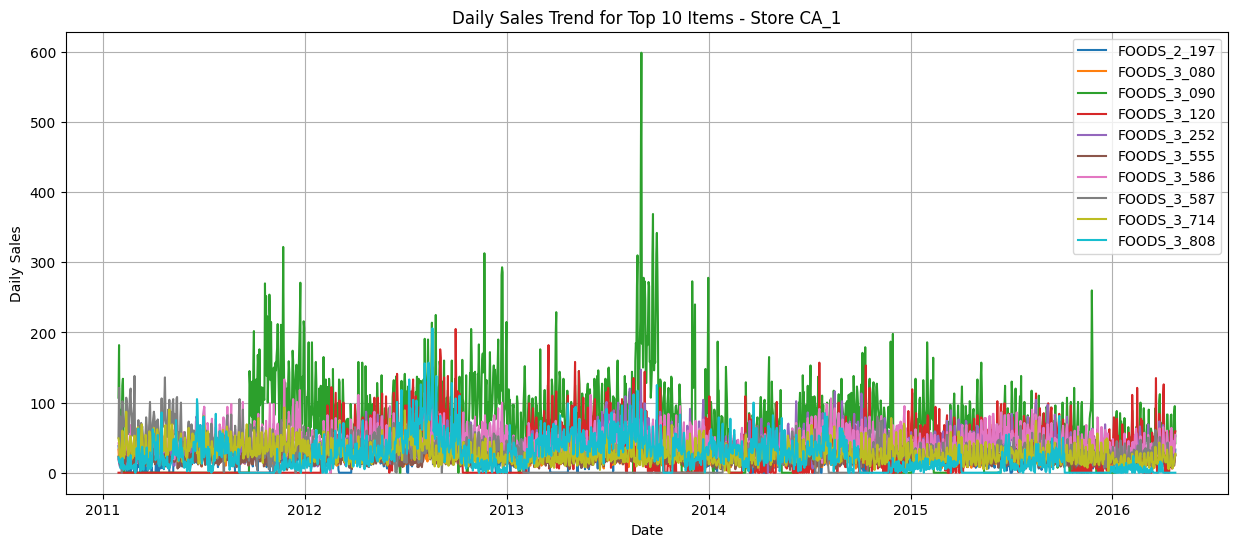

In [14]:
plt.figure(figsize=(15, 6))

for item_id in selected_items_long_df["item_id"].unique():
    temp_df = selected_items_long_df[
        selected_items_long_df["item_id"] == item_id
    ]
    plt.plot(temp_df["date"], temp_df["sales"], label=item_id)

plt.title(f"Daily Sales Trend for Top {TOP_N_ITEMS} Items - Store {SELECTED_STORE}")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.grid(True)
plt.show()

## 3. Baseline Forecasting

Before training SARIMAX models, we create simple baseline forecasts for each selected item.

We use:

1. Naive forecast: last observed value
2. 7-day moving average forecast: average of the last 7 days

This helps us check whether SARIMAX improves over simple forecasting assumptions.

In [15]:
FORECAST_HORIZON = 28

def evaluate_forecast(y_true, y_pred, model_name):
    """
    Evaluate forecast using MAE, RMSE, and MAPE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    y_true_safe = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [16]:
def prepare_item_timeseries(selected_items_long_df, item_name):
    """
    Prepare daily time series data for one item.
    """
    item_df = selected_items_long_df[
        selected_items_long_df["item_id"] == item_name
    ].copy()
    
    item_df = item_df.sort_values("date")
    
    item_ts = item_df[["date", "sales", "snap_CA"]].copy()
    item_ts = item_ts.set_index("date")
    item_ts = item_ts.asfreq("D")
    
    item_ts = item_ts.fillna(0)
    
    return item_ts

In [17]:
def run_item_baselines(selected_items_long_df, item_name, forecast_horizon=28):
    """
    Run naive and 7-day moving average baselines for one item.
    """
    item_ts = prepare_item_timeseries(
        selected_items_long_df=selected_items_long_df,
        item_name=item_name
    )
    
    train_data = item_ts.iloc[:-forecast_horizon].copy()
    test_data = item_ts.iloc[-forecast_horizon:].copy()
    
    y_train_item = train_data["sales"]
    y_test_item = test_data["sales"]
    
    last_observed_value = y_train_item.iloc[-1]
    naive_forecast = np.repeat(last_observed_value, forecast_horizon)
    
    last_7_day_avg = y_train_item.iloc[-7:].mean()
    moving_avg_forecast = np.repeat(last_7_day_avg, forecast_horizon)
    
    naive_results = evaluate_forecast(
        y_true=y_test_item.values,
        y_pred=naive_forecast,
        model_name=f"Naive Forecast - {item_name}"
    )
    
    moving_avg_results = evaluate_forecast(
        y_true=y_test_item.values,
        y_pred=moving_avg_forecast,
        model_name=f"7-Day Moving Average - {item_name}"
    )
    
    naive_results["item_id"] = item_name
    moving_avg_results["item_id"] = item_name
    
    forecast_df = pd.DataFrame({
        "date": y_test_item.index,
        "item_id": item_name,
        "actual_sales": y_test_item.values,
        "naive_forecast": naive_forecast,
        "moving_avg_forecast": moving_avg_forecast
    })
    
    return [naive_results, moving_avg_results], forecast_df

In [18]:
all_items = selected_items_long_df["item_id"].unique().tolist()

all_item_baseline_metrics = []
all_item_baseline_forecasts = []

for item in all_items:
    print("Running baselines for:", item)
    
    metrics, forecast_df = run_item_baselines(
        selected_items_long_df=selected_items_long_df,
        item_name=item,
        forecast_horizon=FORECAST_HORIZON
    )
    
    all_item_baseline_metrics.extend(metrics)
    all_item_baseline_forecasts.append(forecast_df)
    
    print("Done:", item)
    print("-" * 50)

item_baseline_results_df = pd.DataFrame(all_item_baseline_metrics)

item_baseline_results_df.sort_values(["item_id", "MAPE"])

Running baselines for: FOODS_2_197
Done: FOODS_2_197
--------------------------------------------------
Running baselines for: FOODS_3_080
Done: FOODS_3_080
--------------------------------------------------
Running baselines for: FOODS_3_090
Done: FOODS_3_090
--------------------------------------------------
Running baselines for: FOODS_3_120
Done: FOODS_3_120
--------------------------------------------------
Running baselines for: FOODS_3_252
Done: FOODS_3_252
--------------------------------------------------
Running baselines for: FOODS_3_555
Done: FOODS_3_555
--------------------------------------------------
Running baselines for: FOODS_3_586
Done: FOODS_3_586
--------------------------------------------------
Running baselines for: FOODS_3_587
Done: FOODS_3_587
--------------------------------------------------
Running baselines for: FOODS_3_714
Done: FOODS_3_714
--------------------------------------------------
Running baselines for: FOODS_3_808
Done: FOODS_3_808
-----------

,model,MAE,RMSE,MAPE,item_id
0,Naive Forecast - FOODS_2_197,9.321429,12.149368,39.604913,FOODS_2_197
1,7-Day Moving Average - FOODS_2_197,9.607143,12.531389,40.099917,FOODS_2_197
2,Naive Forecast - FOODS_3_080,5.535714,6.505492,34.785213,FOODS_3_080
3,7-Day Moving Average - FOODS_3_080,6.576531,7.713294,49.298291,FOODS_3_080
5,7-Day Moving Average - FOODS_3_090,21.464286,23.663565,56.946104,FOODS_3_090
4,Naive Forecast - FOODS_3_090,61.178571,64.801069,163.759385,FOODS_3_090
7,7-Day Moving Average - FOODS_3_120,24.464286,31.526066,141.344504,FOODS_3_120
6,Naive Forecast - FOODS_3_120,37.678571,44.004464,257.533550,FOODS_3_120
9,7-Day Moving Average - FOODS_3_252,10.525510,12.674295,30.842894,FOODS_3_252
8,Naive Forecast - FOODS_3_252,18.035714,20.766560,63.680947,FOODS_3_252


In [19]:
best_item_baseline_df = (
    item_baseline_results_df
    .sort_values(["item_id", "MAPE"])
    .groupby("item_id", as_index=False)
    .first()
)

best_item_baseline_df

,item_id,model,MAE,RMSE,MAPE
0,FOODS_2_197,Naive Forecast - FOODS_2_197,9.321429,12.149368,39.604913
1,FOODS_3_080,Naive Forecast - FOODS_3_080,5.535714,6.505492,34.785213
2,FOODS_3_090,7-Day Moving Average - FOODS_3_090,21.464286,23.663565,56.946104
3,FOODS_3_120,7-Day Moving Average - FOODS_3_120,24.464286,31.526066,141.344504
4,FOODS_3_252,7-Day Moving Average - FOODS_3_252,10.525510,12.674295,30.842894
5,FOODS_3_555,7-Day Moving Average - FOODS_3_555,5.448980,6.449173,30.933296
6,FOODS_3_586,7-Day Moving Average - FOODS_3_586,10.352041,12.144328,30.103426
7,FOODS_3_587,7-Day Moving Average - FOODS_3_587,15.658163,17.177495,89.046665
8,FOODS_3_714,7-Day Moving Average - FOODS_3_714,9.127551,10.683050,88.382301
9,FOODS_3_808,7-Day Moving Average - FOODS_3_808,2.852041,3.929870,75.453297


## 4. SNAP-only SARIMAX Tuning

Now we train SARIMAX models for each selected item using sales history and SNAP as the external variable.

Since item-level forecasting is noisier and more computationally expensive, we test a smaller set of SARIMAX configurations.

In [20]:
item_sarimax_configs = [
    {
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (1, 1, 1),
        "seasonal_order": (0, 1, 1, 7)
    },
    {
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 7)
    }
]

In [21]:
def run_item_sarimax_pipeline(
    selected_items_long_df,
    item_name,
    forecast_horizon=28,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
):
    """
    Run SARIMAX forecasting pipeline for one item using SNAP as exogenous variable.
    """
    
    item_ts = prepare_item_timeseries(
        selected_items_long_df=selected_items_long_df,
        item_name=item_name
    )
    
    train_data = item_ts.iloc[:-forecast_horizon].copy()
    test_data = item_ts.iloc[-forecast_horizon:].copy()
    
    y_train_item = train_data["sales"]
    y_test_item = test_data["sales"]
    
    X_train_item = train_data[["snap_CA"]]
    X_test_item = test_data[["snap_CA"]]
    
    model = SARIMAX(
        y_train_item,
        exog=X_train_item,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False, maxiter=100)
    
    forecast_result = result.get_forecast(
        steps=forecast_horizon,
        exog=X_test_item
    )
    
    forecast_values = forecast_result.predicted_mean
    
    # Item-level forecast should not go below zero
    forecast_values = forecast_values.clip(lower=0)
    
    metrics = evaluate_forecast(
        y_true=y_test_item.values,
        y_pred=forecast_values.values,
        model_name=f"SARIMAX {order}{seasonal_order} - {item_name}"
    )
    
    metrics["item_id"] = item_name
    metrics["AIC"] = result.aic
    metrics["order"] = order
    metrics["seasonal_order"] = seasonal_order
    metrics["converged"] = result.mle_retvals.get("converged", None)
    metrics["feature_set"] = "snap_only"
    
    forecast_df = pd.DataFrame({
        "date": y_test_item.index,
        "item_id": item_name,
        "actual_sales": y_test_item.values,
        "sarimax_forecast": forecast_values.values
    })
    
    return metrics, forecast_df, result

In [22]:
def tune_sarimax_for_item(
    selected_items_long_df,
    item_name,
    configs,
    forecast_horizon=28
):
    """
    Tune SARIMAX models for one item and return all results.
    """
    
    item_results = []
    item_models = {}
    item_forecasts = {}
    
    for config in configs:
        order = config["order"]
        seasonal_order = config["seasonal_order"]
        
        model_label = f"SARIMAX {order}{seasonal_order} - {item_name}"
        
        print("Training:", model_label)
        
        try:
            metrics, forecast_df, model_result = run_item_sarimax_pipeline(
                selected_items_long_df=selected_items_long_df,
                item_name=item_name,
                forecast_horizon=forecast_horizon,
                order=order,
                seasonal_order=seasonal_order
            )
            
            metrics["model_label"] = model_label
            
            item_results.append(metrics)
            item_models[model_label] = model_result
            item_forecasts[model_label] = forecast_df
            
            print("Done:", model_label)
            print("MAPE:", round(metrics["MAPE"], 2), "%")
            print("Converged:", metrics["converged"])
            print("-" * 50)
            
        except Exception as e:
            print("Failed:", model_label)
            print("Error:", e)
            print("-" * 50)
    
    item_results_df = pd.DataFrame(item_results)
    
    if item_results_df.empty:
        return item_results_df, item_models, item_forecasts
    
    item_results_df = item_results_df.sort_values("MAPE")
    
    return item_results_df, item_models, item_forecasts

In [23]:
all_item_tuned_results = []
all_item_tuned_models = {}
all_item_tuned_forecasts = {}

for item in all_items:
    print("=" * 70)
    print("Tuning item:", item)
    print("=" * 70)
    
    item_results_df, item_models, item_forecasts = tune_sarimax_for_item(
        selected_items_long_df=selected_items_long_df,
        item_name=item,
        configs=item_sarimax_configs,
        forecast_horizon=FORECAST_HORIZON
    )
    
    if item_results_df.empty:
        print("No successful model for:", item)
        continue
    
    best_row = item_results_df.iloc[0]
    best_model_label = best_row["model_label"]
    
    all_item_tuned_results.append(best_row)
    all_item_tuned_models[item] = item_models[best_model_label]
    all_item_tuned_forecasts[item] = item_forecasts[best_model_label]
    
    print("Best model for", item)
    print("Model:", best_model_label)
    print("MAPE:", round(best_row["MAPE"], 2), "%")
    print()

Tuning item: FOODS_2_197
Training: SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_2_197
Done: SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_2_197
MAPE: 36.84 %
Converged: True
--------------------------------------------------
Training: SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_2_197
Done: SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_2_197
MAPE: 40.15 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197
Done: SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197
MAPE: 36.68 %
Converged: True
--------------------------------------------------
Training: SARIMAX (0, 1, 1)(0, 1, 1, 7) - FOODS_2_197
Done: SARIMAX (0, 1, 1)(0, 1, 1, 7) - FOODS_2_197
MAPE: 39.35 %
Converged: True
--------------------------------------------------
Best model for FOODS_2_197
Model: SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197
MAPE: 36.68 %

Tuning item: FOODS_3_080
Training: SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_080
Done: SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_080
MAPE: 32.7 %


In [24]:
all_item_tuned_results_df = pd.DataFrame(all_item_tuned_results)

all_item_tuned_results_df = all_item_tuned_results_df[
    [
        "item_id",
        "model",
        "feature_set",
        "order",
        "seasonal_order",
        "MAE",
        "RMSE",
        "MAPE",
        "AIC",
        "converged"
    ]
].sort_values("MAPE")

all_item_tuned_results_df

,item_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
2,FOODS_3_586,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_3_586",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",6.303738,7.420563,17.461578,14235.381793,True
0,FOODS_3_252,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_252",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",6.231376,8.044694,17.820671,14396.468814,True
1,FOODS_3_555,"SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_3_555",snap_only,"(0, 1, 1)","(1, 1, 1, 7)",3.183782,4.032554,18.022815,12103.504785,True
2,FOODS_3_080,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_3_080",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",4.863148,6.130504,32.687441,12070.480101,True
0,FOODS_3_714,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_714",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",4.483582,5.360554,36.286553,13602.348736,True
2,FOODS_2_197,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",8.092793,10.779482,36.684273,13714.036197,True
0,FOODS_3_090,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_090",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",17.318621,21.150638,49.570927,18635.331106,True
0,FOODS_3_587,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_587",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",17.250234,18.213568,92.446449,14086.415960,True
0,FOODS_3_808,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_808",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",3.253566,4.415247,99.208560,14966.368114,True
0,FOODS_3_120,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_120",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",21.745800,29.352469,143.954544,16583.293108,True


## 5. Calendar-Feature SARIMAX Experiment

The SNAP-only SARIMAX models improved some item-level forecasts, but item-level demand remains noisy and irregular.

Now we test whether additional calendar features improve performance:

- SNAP indicator
- weekday dummy variables
- month dummy variables
- event indicator

We compare this against the SNAP-only SARIMAX models and select the final stable model per item.

In [25]:
def prepare_item_timeseries_with_features(selected_items_long_df, item_name):
    """
    Prepare daily item time series with numeric calendar exogenous features.
    """
    item_df = selected_items_long_df[
        selected_items_long_df["item_id"] == item_name
    ].copy()
    
    item_df = item_df.sort_values("date")
    
    item_df["is_event"] = item_df["event_name_1"].notna().astype(int)
    
    item_ts = item_df[
        ["date", "sales", "snap_CA", "weekday", "month", "is_event"]
    ].copy()
    
    item_ts = item_ts.set_index("date")
    item_ts = item_ts.asfreq("D")
    
    weekday_dummies = pd.get_dummies(
        item_ts["weekday"],
        prefix="weekday",
        drop_first=True,
        dtype=int
    )
    
    month_dummies = pd.get_dummies(
        item_ts["month"].astype(str),
        prefix="month",
        drop_first=True,
        dtype=int
    )
    
    item_ts = pd.concat(
        [
            item_ts[["sales", "snap_CA", "is_event"]],
            weekday_dummies,
            month_dummies
        ],
        axis=1
    )
    
    item_ts = item_ts.fillna(0)
    item_ts = item_ts.apply(pd.to_numeric, errors="coerce").fillna(0)
    item_ts = item_ts.astype(float)
    
    return item_ts

In [26]:
test_item_ts = prepare_item_timeseries_with_features(
    selected_items_long_df=selected_items_long_df,
    item_name="FOODS_3_586"
)

print(test_item_ts.shape)
print(test_item_ts.dtypes)

test_item_ts.head()

(1913, 20)
sales                float64
snap_CA              float64
is_event             float64
weekday_Monday       float64
weekday_Saturday     float64
weekday_Sunday       float64
weekday_Thursday     float64
weekday_Tuesday      float64
weekday_Wednesday    float64
month_10             float64
month_11             float64
month_12             float64
month_2              float64
month_3              float64
month_4              float64
month_5              float64
month_6              float64
month_7              float64
month_8              float64
month_9              float64
dtype: object


,sales,snap_CA,is_event,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,month_10,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
date,,,,,,,,,,,,,,,,,,,,
2011-01-29,42.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-30,36.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-31,30.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-01,23.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-02,27.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
def run_item_sarimax_with_calendar_features(
    selected_items_long_df,
    item_name,
    forecast_horizon=28,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
):
    """
    Run SARIMAX with SNAP + weekday + month + event features for one item.
    """
    
    item_ts = prepare_item_timeseries_with_features(
        selected_items_long_df=selected_items_long_df,
        item_name=item_name
    )
    
    train_data = item_ts.iloc[:-forecast_horizon].copy()
    test_data = item_ts.iloc[-forecast_horizon:].copy()
    
    y_train_item = train_data["sales"]
    y_test_item = test_data["sales"]
    
    X_train_item = train_data.drop(columns=["sales"])
    X_test_item = test_data.drop(columns=["sales"])
    
    model = SARIMAX(
        y_train_item,
        exog=X_train_item,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False, maxiter=100)
    
    forecast_result = result.get_forecast(
        steps=forecast_horizon,
        exog=X_test_item
    )
    
    forecast_values = forecast_result.predicted_mean
    
    # Item-level forecast should not go below zero
    forecast_values = forecast_values.clip(lower=0)
    
    metrics = evaluate_forecast(
        y_true=y_test_item.values,
        y_pred=forecast_values.values,
        model_name=f"Calendar SARIMAX {order}{seasonal_order} - {item_name}"
    )
    
    metrics["item_id"] = item_name
    metrics["AIC"] = result.aic
    metrics["order"] = order
    metrics["seasonal_order"] = seasonal_order
    metrics["converged"] = result.mle_retvals.get("converged", None)
    metrics["feature_set"] = "snap_weekday_month_event"
    
    forecast_df = pd.DataFrame({
        "date": y_test_item.index,
        "item_id": item_name,
        "actual_sales": y_test_item.values,
        "calendar_sarimax_forecast": forecast_values.values
    })
    
    return metrics, forecast_df, result

In [28]:
def tune_calendar_sarimax_for_item(
    selected_items_long_df,
    item_name,
    configs,
    forecast_horizon=28
):
    """
    Tune calendar-feature SARIMAX models for one item.
    """
    
    item_results = []
    item_models = {}
    item_forecasts = {}
    
    for config in configs:
        order = config["order"]
        seasonal_order = config["seasonal_order"]
        
        model_label = f"Calendar SARIMAX {order}{seasonal_order} - {item_name}"
        
        print("Training:", model_label)
        
        try:
            metrics, forecast_df, model_result = run_item_sarimax_with_calendar_features(
                selected_items_long_df=selected_items_long_df,
                item_name=item_name,
                forecast_horizon=forecast_horizon,
                order=order,
                seasonal_order=seasonal_order
            )
            
            metrics["model_label"] = model_label
            
            item_results.append(metrics)
            item_models[model_label] = model_result
            item_forecasts[model_label] = forecast_df
            
            print("Done:", model_label)
            print("MAPE:", round(metrics["MAPE"], 2), "%")
            print("Converged:", metrics["converged"])
            print("-" * 50)
            
        except Exception as e:
            print("Failed:", model_label)
            print("Error:", e)
            print("-" * 50)
    
    item_results_df = pd.DataFrame(item_results)
    
    if item_results_df.empty:
        return item_results_df, item_models, item_forecasts
    
    item_results_df = item_results_df.sort_values("MAPE")
    
    return item_results_df, item_models, item_forecasts

In [29]:
all_item_calendar_results = []
all_item_calendar_models = {}
all_item_calendar_forecasts = {}

for item in all_items:
    print("=" * 70)
    print("Calendar feature tuning for item:", item)
    print("=" * 70)
    
    item_results_df, item_models, item_forecasts = tune_calendar_sarimax_for_item(
        selected_items_long_df=selected_items_long_df,
        item_name=item,
        configs=item_sarimax_configs,
        forecast_horizon=FORECAST_HORIZON
    )
    
    if item_results_df.empty:
        print("No successful calendar model for:", item)
        continue
    
    best_row = item_results_df.iloc[0]
    best_model_label = best_row["model_label"]
    
    all_item_calendar_results.append(best_row)
    all_item_calendar_models[item] = item_models[best_model_label]
    all_item_calendar_forecasts[item] = item_forecasts[best_model_label]
    
    print("Best calendar model for", item)
    print("Model:", best_model_label)
    print("MAPE:", round(best_row["MAPE"], 2), "%")
    print()

Calendar feature tuning for item: FOODS_2_197
Training: Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_2_197
Done: Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_2_197
MAPE: 31.67 %
Converged: False
--------------------------------------------------
Training: Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_2_197
Done: Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_2_197
MAPE: 32.65 %
Converged: False
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197
Done: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197
MAPE: 31.56 %
Converged: False
--------------------------------------------------
Training: Calendar SARIMAX (0, 1, 1)(0, 1, 1, 7) - FOODS_2_197
Done: Calendar SARIMAX (0, 1, 1)(0, 1, 1, 7) - FOODS_2_197
MAPE: 34.26 %
Converged: False
--------------------------------------------------
Best calendar model for FOODS_2_197
Model: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197
MAPE: 31.56 %

Calendar feature tuning for

In [30]:
all_item_calendar_results_df = pd.DataFrame(all_item_calendar_results)

all_item_calendar_results_df = all_item_calendar_results_df[
    [
        "item_id",
        "model",
        "feature_set",
        "order",
        "seasonal_order",
        "MAE",
        "RMSE",
        "MAPE",
        "AIC",
        "converged"
    ]
].sort_values("MAPE")

all_item_calendar_results_df

,item_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
2,FOODS_3_586,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",6.132142,7.393705,16.223470,14244.177116,False
3,FOODS_3_555,"Calendar SARIMAX (0, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(0, 1, 1)","(0, 1, 1, 7)",3.190507,4.091788,17.712801,12132.355103,False
1,FOODS_3_252,"Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(0, 1, 1)","(1, 1, 1, 7)",7.071235,8.946986,19.557345,14550.080828,False
2,FOODS_3_714,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",4.240797,5.306644,30.004944,13647.053429,False
2,FOODS_2_197,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",6.476589,8.757503,31.560518,13737.438293,False
3,FOODS_3_080,"Calendar SARIMAX (0, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(0, 1, 1)","(0, 1, 1, 7)",4.878769,6.087011,32.361841,12135.683686,False
2,FOODS_3_090,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",16.196674,19.938939,46.725859,18683.786337,True
0,FOODS_3_808,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",5.529596,6.249875,79.121217,14984.848624,False
0,FOODS_3_587,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",19.426601,20.363975,103.440371,14113.553200,False
0,FOODS_3_120,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",23.667969,28.567025,123.391813,16612.697846,False


## 6. Feature Experiment Comparison

We compare two item-level SARIMAX setups:

1. SNAP-only SARIMAX
2. Calendar-feature SARIMAX using SNAP, weekday, month, and event indicators

At item level, calendar features improved some scores but caused convergence issues for many models.

For final model selection, we prioritize stable models that converged successfully.

In [31]:
snap_only_item_results_df = all_item_tuned_results_df.copy()
calendar_item_results_df = all_item_calendar_results_df.copy()

item_feature_comparison_df = pd.concat(
    [
        snap_only_item_results_df[
            [
                "item_id",
                "model",
                "feature_set",
                "order",
                "seasonal_order",
                "MAE",
                "RMSE",
                "MAPE",
                "AIC",
                "converged"
            ]
        ],
        calendar_item_results_df[
            [
                "item_id",
                "model",
                "feature_set",
                "order",
                "seasonal_order",
                "MAE",
                "RMSE",
                "MAPE",
                "AIC",
                "converged"
            ]
        ]
    ],
    ignore_index=True
)

item_feature_comparison_df = item_feature_comparison_df.sort_values(
    ["item_id", "MAPE"]
)

item_feature_comparison_df

,item_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
14,FOODS_2_197,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",6.476589,8.757503,31.560518,13737.438293,False
5,FOODS_2_197,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",8.092793,10.779482,36.684273,13714.036197,True
15,FOODS_3_080,"Calendar SARIMAX (0, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(0, 1, 1)","(0, 1, 1, 7)",4.878769,6.087011,32.361841,12135.683686,False
3,FOODS_3_080,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_3_080",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",4.863148,6.130504,32.687441,12070.480101,True
16,FOODS_3_090,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",16.196674,19.938939,46.725859,18683.786337,True
6,FOODS_3_090,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_090",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",17.318621,21.150638,49.570927,18635.331106,True
19,FOODS_3_120,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",23.667969,28.567025,123.391813,16612.697846,False
9,FOODS_3_120,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_120",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",21.745800,29.352469,143.954544,16583.293108,True
1,FOODS_3_252,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_252",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",6.231376,8.044694,17.820671,14396.468814,True
12,FOODS_3_252,"Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(0, 1, 1)","(1, 1, 1, 7)",7.071235,8.946986,19.557345,14550.080828,False


In [32]:
final_item_selected_models_df = (
    item_feature_comparison_df
    .sort_values(["item_id", "converged", "MAPE"], ascending=[True, False, True])
    .groupby("item_id", as_index=False)
    .first()
)

final_item_selected_models_df

,item_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
0,FOODS_2_197,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",8.092793,10.779482,36.684273,13714.036197,True
1,FOODS_3_080,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_3_080",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",4.863148,6.130504,32.687441,12070.480101,True
2,FOODS_3_090,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",16.196674,19.938939,46.725859,18683.786337,True
3,FOODS_3_120,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_120",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",21.745800,29.352469,143.954544,16583.293108,True
4,FOODS_3_252,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_252",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",6.231376,8.044694,17.820671,14396.468814,True
5,FOODS_3_555,"SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_3_555",snap_only,"(0, 1, 1)","(1, 1, 1, 7)",3.183782,4.032554,18.022815,12103.504785,True
6,FOODS_3_586,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_3_586",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",6.303738,7.420563,17.461578,14235.381793,True
7,FOODS_3_587,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_587",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",17.250234,18.213568,92.446449,14086.415960,True
8,FOODS_3_714,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_714",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",4.483582,5.360554,36.286553,13602.348736,True
9,FOODS_3_808,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_808",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",3.253566,4.415247,99.208560,14966.368114,True


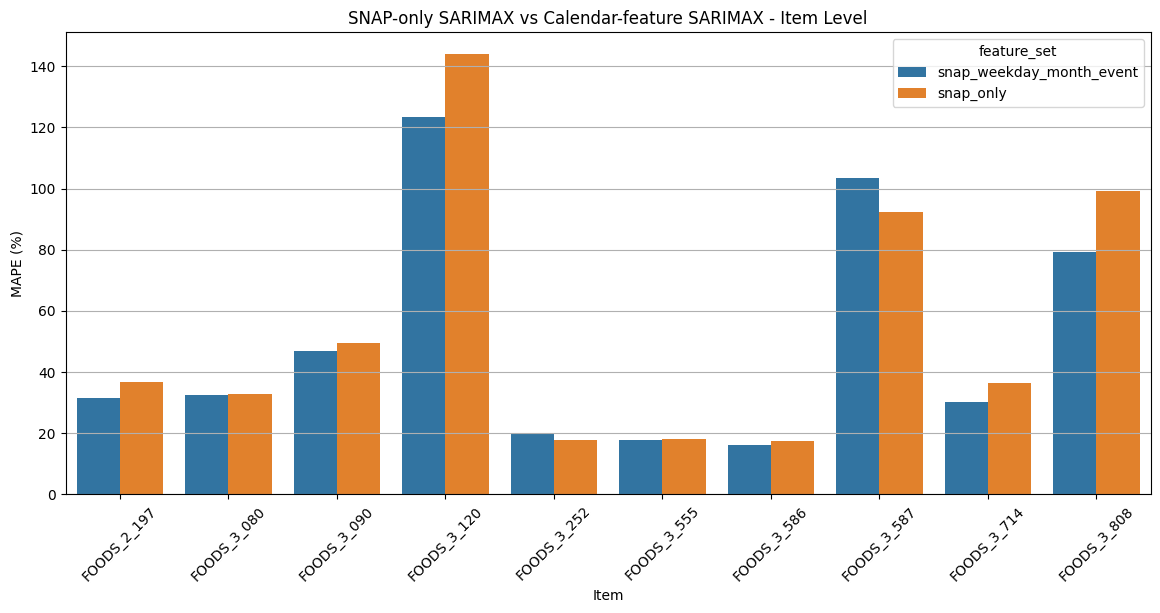

In [33]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=item_feature_comparison_df,
    x="item_id",
    y="MAPE",
    hue="feature_set"
)

plt.title("SNAP-only SARIMAX vs Calendar-feature SARIMAX - Item Level")
plt.xlabel("Item")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [34]:
item_feature_comparison_path = os.path.join(
    OUTPUTS_DIR,
    f"item_feature_comparison_sarimax_top_{TOP_N_ITEMS}_{SELECTED_STORE}.csv"
)

final_item_selected_models_path = os.path.join(
    OUTPUTS_DIR,
    f"final_item_selected_models_top_{TOP_N_ITEMS}_{SELECTED_STORE}.csv"
)

item_feature_comparison_df.to_csv(
    item_feature_comparison_path,
    index=False
)

final_item_selected_models_df.to_csv(
    final_item_selected_models_path,
    index=False
)

print("Item feature comparison saved to:")
print(item_feature_comparison_path)

print("\nFinal selected item models saved to:")
print(final_item_selected_models_path)

Item feature comparison saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\item_feature_comparison_sarimax_top_10_CA_1.csv

Final selected item models saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_item_selected_models_top_10_CA_1.csv


In [35]:
final_item_forecast_list = []

for _, row in final_item_selected_models_df.iterrows():
    item = row["item_id"]
    feature_set = row["feature_set"]
    
    if feature_set == "snap_only":
        forecast_df = all_item_tuned_forecasts[item].copy()
        forecast_df = forecast_df.rename(
            columns={"sarimax_forecast": "final_forecast"}
        )
    else:
        forecast_df = all_item_calendar_forecasts[item].copy()
        forecast_df = forecast_df.rename(
            columns={"calendar_sarimax_forecast": "final_forecast"}
        )
    
    forecast_df["feature_set"] = feature_set
    forecast_df["selected_model"] = row["model"]
    
    final_item_forecast_list.append(forecast_df)

final_item_forecasts_df = pd.concat(
    final_item_forecast_list,
    ignore_index=True
)

final_item_forecasts_df["error"] = (
    final_item_forecasts_df["actual_sales"]
    - final_item_forecasts_df["final_forecast"]
)

final_item_forecasts_df["absolute_error"] = (
    final_item_forecasts_df["error"].abs()
)

final_item_forecasts_df["absolute_percentage_error"] = (
    final_item_forecasts_df["absolute_error"]
    / final_item_forecasts_df["actual_sales"].replace(0, np.nan)
) * 100

print("Final item forecast shape:", final_item_forecasts_df.shape)

final_item_forecasts_df.head()

Final item forecast shape: (280, 9)


,date,item_id,actual_sales,final_forecast,feature_set,selected_model,error,absolute_error,absolute_percentage_error
0,2016-03-28,FOODS_2_197,26.0,10.566512,snap_only,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197",15.433488,15.433488,59.359569
1,2016-03-29,FOODS_2_197,12.0,9.863073,snap_only,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197",2.136927,2.136927,17.807729
2,2016-03-30,FOODS_2_197,12.0,7.296059,snap_only,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197",4.703941,4.703941,39.199505
3,2016-03-31,FOODS_2_197,9.0,5.594719,snap_only,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197",3.405281,3.405281,37.836455
4,2016-04-01,FOODS_2_197,9.0,13.814980,snap_only,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197",-4.814980,4.814980,53.499780


In [36]:
item_forecast_summary_df = (
    final_item_forecasts_df
    .groupby("item_id", as_index=False)
    .agg(
        forecast_days=("date", "count"),
        avg_actual_sales=("actual_sales", "mean"),
        avg_forecast_sales=("final_forecast", "mean"),
        avg_absolute_error=("absolute_error", "mean"),
        avg_percentage_error=("absolute_percentage_error", "mean")
    )
    .sort_values("avg_percentage_error")
)

item_forecast_summary_df

,item_id,forecast_days,avg_actual_sales,avg_forecast_sales,avg_absolute_error,avg_percentage_error
6,FOODS_3_586,28,38.392857,39.881102,6.303738,17.461578
4,FOODS_3_252,28,37.535714,35.664885,6.231376,17.820671
5,FOODS_3_555,28,19.142857,18.446390,3.183782,18.022815
1,FOODS_3_080,28,18.535714,19.626023,4.863148,32.687441
8,FOODS_3_714,28,18.750000,20.210883,4.483582,36.286553
0,FOODS_2_197,28,19.964286,12.659601,8.092793,36.684273
2,FOODS_3_090,28,50.821429,62.164277,16.196674,46.725859
7,FOODS_3_587,28,22.964286,40.214520,17.250234,92.446449
9,FOODS_3_808,28,1.392857,2.369784,3.253566,99.208560
3,FOODS_3_120,28,38.250000,45.310402,21.745800,143.954544


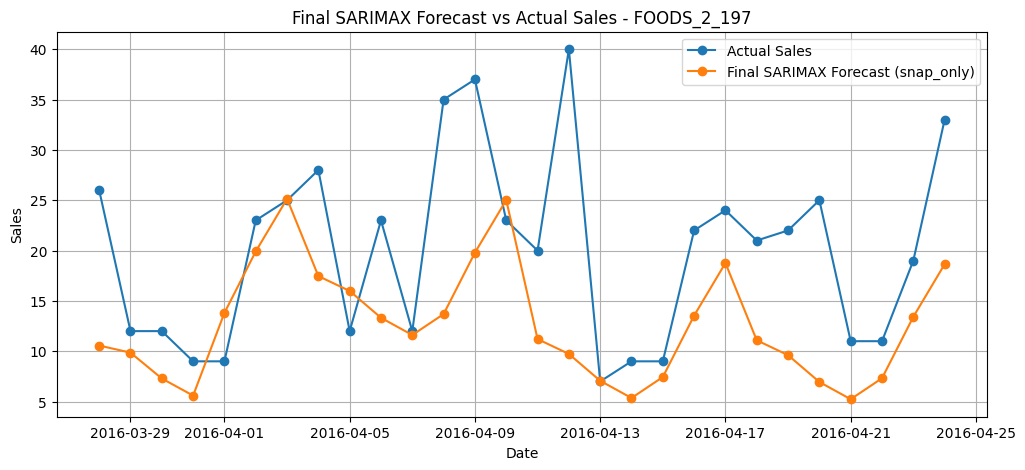

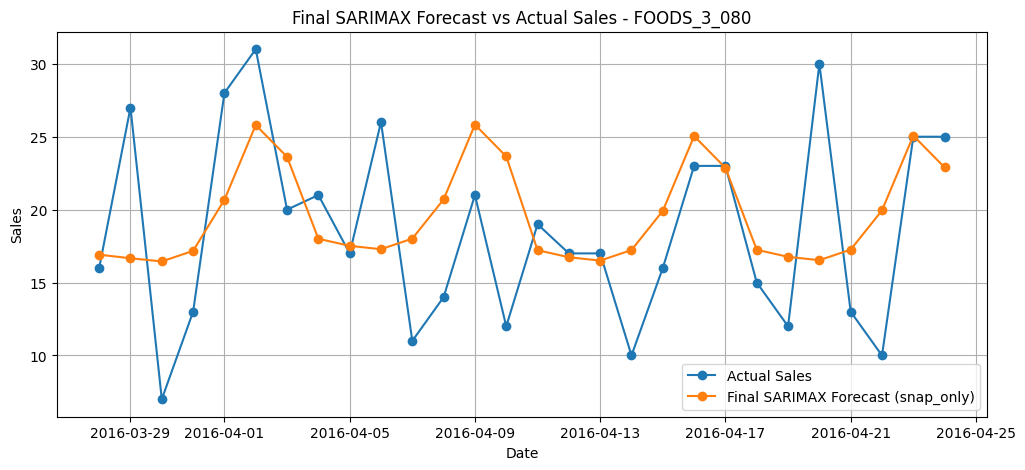

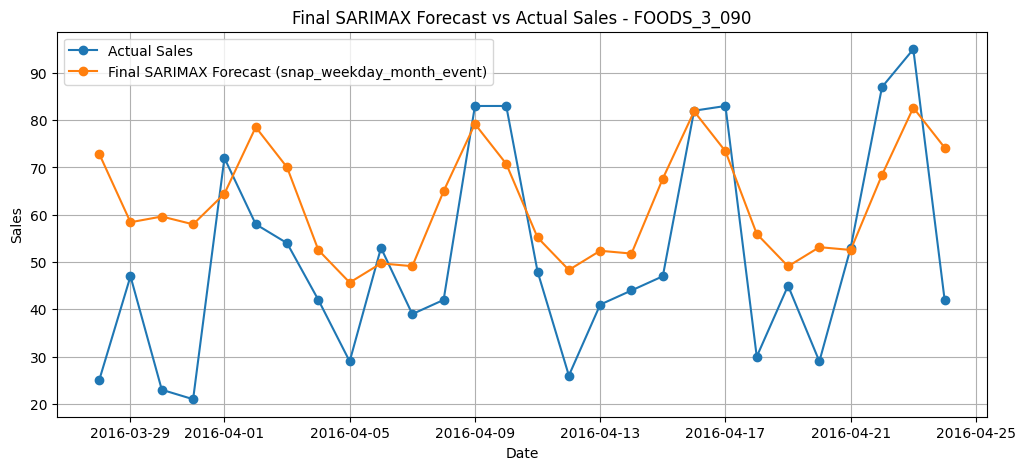

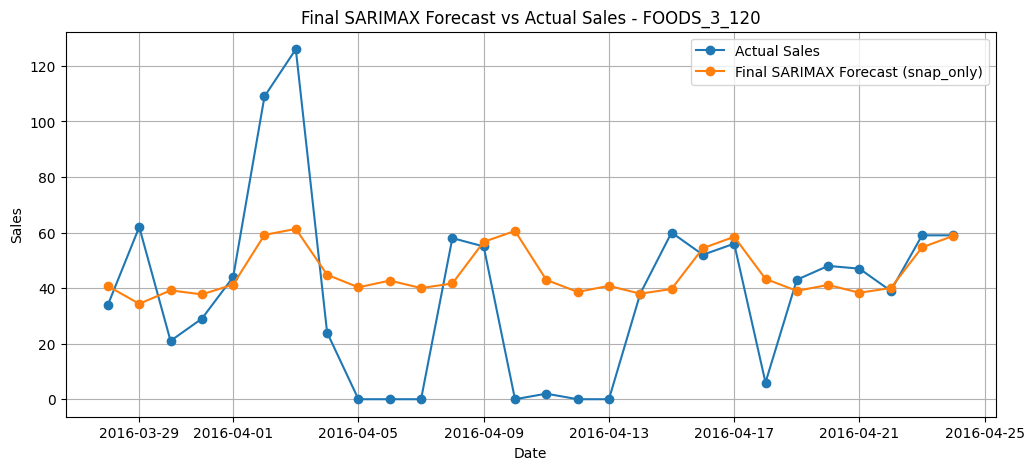

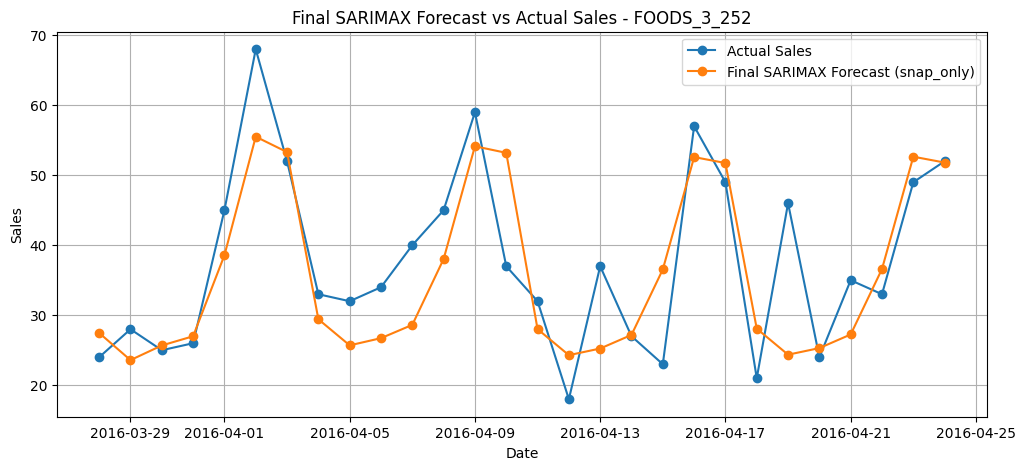

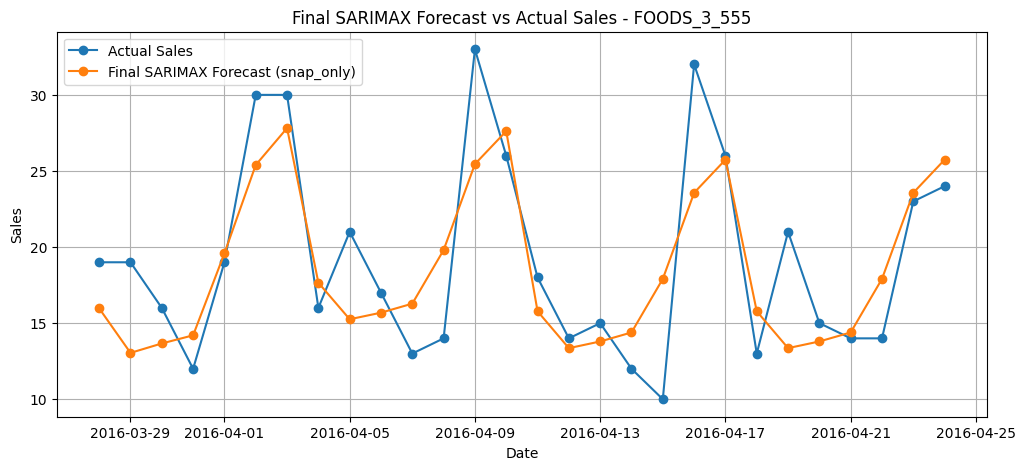

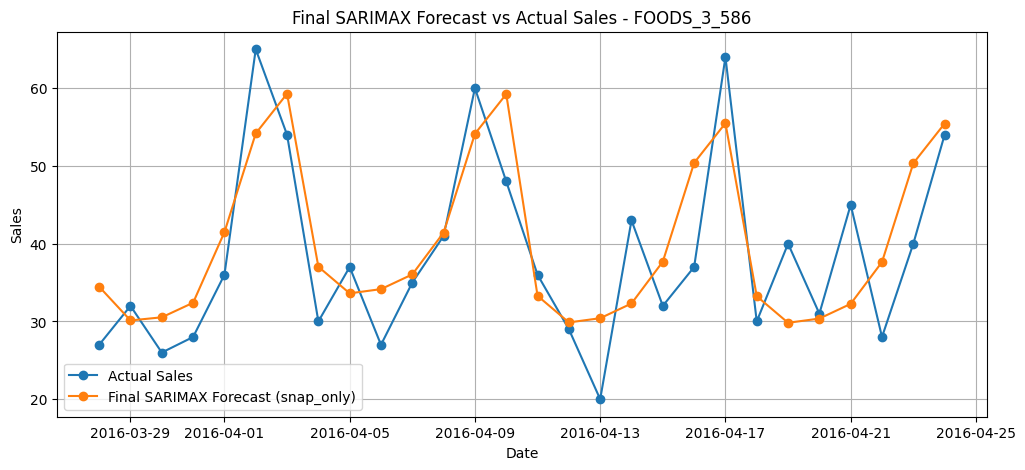

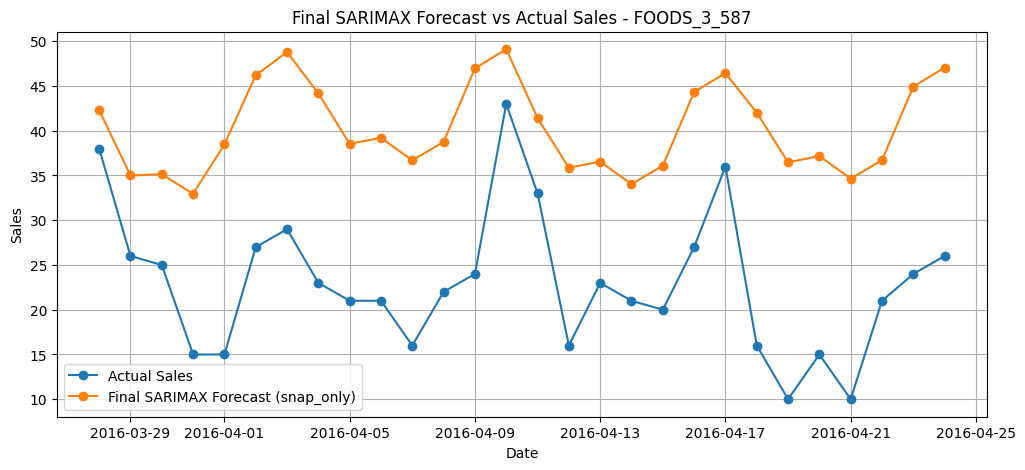

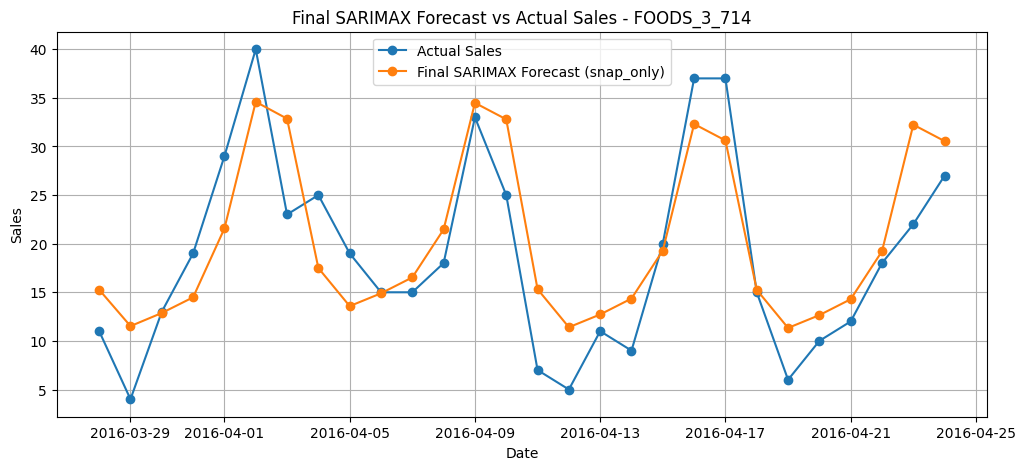

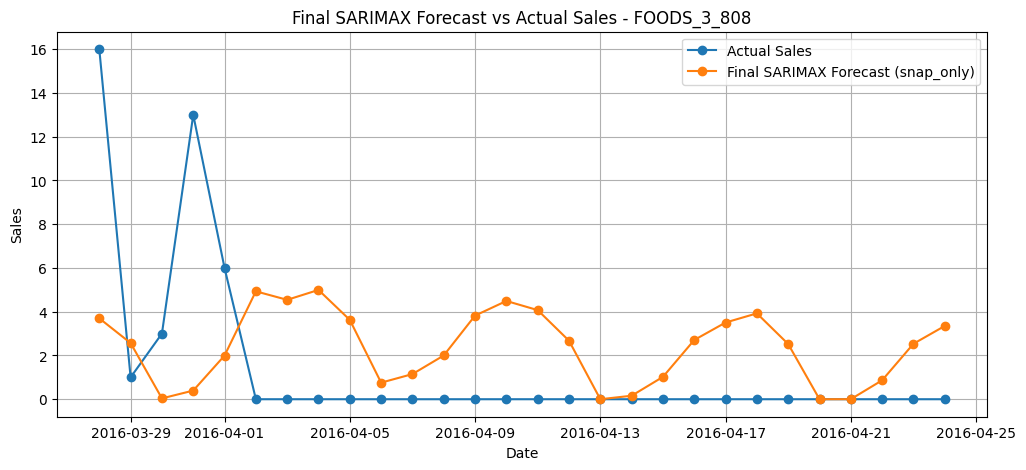

In [37]:
for item in final_item_forecasts_df["item_id"].unique():
    temp_df = final_item_forecasts_df[
        final_item_forecasts_df["item_id"] == item
    ]
    
    selected_feature_set = temp_df["feature_set"].iloc[0]
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(
        temp_df["date"],
        temp_df["actual_sales"],
        label="Actual Sales",
        marker="o"
    )
    
    plt.plot(
        temp_df["date"],
        temp_df["final_forecast"],
        label=f"Final SARIMAX Forecast ({selected_feature_set})",
        marker="o"
    )
    
    plt.title(f"Final SARIMAX Forecast vs Actual Sales - {item}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.show()

In [38]:
final_item_forecasts_path = os.path.join(
    OUTPUTS_DIR,
    f"final_item_sarimax_forecasts_top_{TOP_N_ITEMS}_{SELECTED_STORE}.csv"
)

item_forecast_summary_path = os.path.join(
    OUTPUTS_DIR,
    f"final_item_forecast_summary_top_{TOP_N_ITEMS}_{SELECTED_STORE}.csv"
)

final_item_forecasts_df.to_csv(
    final_item_forecasts_path,
    index=False
)

item_forecast_summary_df.to_csv(
    item_forecast_summary_path,
    index=False
)

print("Final item forecasts saved to:")
print(final_item_forecasts_path)

print("\nItem forecast summary saved to:")
print(item_forecast_summary_path)

Final item forecasts saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_item_sarimax_forecasts_top_10_CA_1.csv

Item forecast summary saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_item_forecast_summary_top_10_CA_1.csv


In [39]:
for _, row in final_item_selected_models_df.iterrows():
    item = row["item_id"]
    feature_set = row["feature_set"]
    
    if feature_set == "snap_only":
        model_result = all_item_tuned_models[item]
    else:
        model_result = all_item_calendar_models[item]
    
    model_path = os.path.join(
        MODELS_DIR,
        f"best_sarimax_item_{item}_{SELECTED_STORE}.pkl"
    )
    
    joblib.dump(model_result, model_path)
    
    print(f"Saved final model for {item}:")
    print(model_path)

Saved final model for FOODS_2_197:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_item_FOODS_2_197_CA_1.pkl
Saved final model for FOODS_3_080:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_item_FOODS_3_080_CA_1.pkl
Saved final model for FOODS_3_090:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_item_FOODS_3_090_CA_1.pkl
Saved final model for FOODS_3_120:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_item_FOODS_3_120_CA_1.pkl
Saved final model for FOODS_3_252:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_item_FOODS_3_252_CA_1.pkl
Saved final model for FOODS_3_555:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_item_FOODS_3_555_CA_1.pkl
Saved final model for FOODS_3_586:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_item_FOODS_3_586_CA_1.pkl
Saved final m

In [40]:
final_item_notebook_summary = {
    "store": SELECTED_STORE,
    "forecast_level": "item",
    "forecast_horizon_days": FORECAST_HORIZON,
    "number_of_items": TOP_N_ITEMS,
    "best_item": item_forecast_summary_df.iloc[0]["item_id"],
    "best_item_mape": item_forecast_summary_df.iloc[0]["avg_percentage_error"],
    "weakest_item": item_forecast_summary_df.iloc[-1]["item_id"],
    "weakest_item_mape": item_forecast_summary_df.iloc[-1]["avg_percentage_error"],
    "average_mape_across_items": item_forecast_summary_df["avg_percentage_error"].mean()
}

final_item_notebook_summary_df = pd.DataFrame([final_item_notebook_summary])

final_item_summary_path = os.path.join(
    OUTPUTS_DIR,
    f"final_item_forecasting_summary_top_{TOP_N_ITEMS}_{SELECTED_STORE}.csv"
)

final_item_notebook_summary_df.to_csv(
    final_item_summary_path,
    index=False
)

print("Final item forecasting summary saved to:")
print(final_item_summary_path)

final_item_notebook_summary_df

Final item forecasting summary saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_item_forecasting_summary_top_10_CA_1.csv


,store,forecast_level,forecast_horizon_days,number_of_items,best_item,best_item_mape,weakest_item,weakest_item_mape,average_mape_across_items
0,CA_1,item,28,10,FOODS_3_586,17.461578,FOODS_3_120,143.954544,54.129874


## 7. Final Conclusion

This notebook built an item-level forecasting pipeline for the top-selling items in Walmart store CA_1 using the M5 dataset.

Unlike category, department, and store-level forecasting, item-level forecasting is significantly harder because individual product demand is sparse, noisy, and affected by sudden spikes.

We selected the top 10 highest-selling items in CA_1 and trained baseline models, SNAP-only SARIMAX models, and calendar-feature SARIMAX models.

### Final Item-Level Insights

- The best-performing items were FOODS_3_586, FOODS_3_252, and FOODS_3_555, with MAPE around 17% to 18%.
- Several items had very high MAPE because their actual demand was irregular or contained many zero-sales days.
- Calendar features improved some raw MAPE values, but many calendar-feature models failed to converge.
- For final selection, stable converged models were prioritized.
- Item-level SARIMAX is useful as a baseline, but not sufficient for highly irregular item demand.

### Business Takeaways

1. Item-level forecasting is much harder than category, department, and store-level forecasting.
2. Aggregated forecasting gives more stable and reliable predictions.
3. High-volume items with consistent daily sales are easier to forecast.
4. Items with frequent zero-sales days require special modeling strategies.
5. Future improvement should include price, promotions, stock availability, rolling features, and machine learning models such as LightGBM or XGBoost.

In [41]:
print("Item-level notebook completed successfully.")
print()
print("Saved files:")
print("1.", item_processed_path)
print("2.", item_feature_comparison_path)
print("3.", final_item_selected_models_path)
print("4.", final_item_forecasts_path)
print("5.", item_forecast_summary_path)
print("6.", final_item_summary_path)

Item-level notebook completed successfully.

Saved files:
1. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\processed\top_10_item_daily_sales_CA_1.csv
2. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\item_feature_comparison_sarimax_top_10_CA_1.csv
3. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_item_selected_models_top_10_CA_1.csv
4. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_item_sarimax_forecasts_top_10_CA_1.csv
5. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_item_forecast_summary_top_10_CA_1.csv
6. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_item_forecasting_summary_top_10_CA_1.csv


In [42]:
final_item_selected_models_df.sort_values("MAPE")

,item_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
6,FOODS_3_586,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_3_586",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",6.303738,7.420563,17.461578,14235.381793,True
4,FOODS_3_252,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_252",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",6.231376,8.044694,17.820671,14396.468814,True
5,FOODS_3_555,"SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_3_555",snap_only,"(0, 1, 1)","(1, 1, 1, 7)",3.183782,4.032554,18.022815,12103.504785,True
1,FOODS_3_080,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_3_080",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",4.863148,6.130504,32.687441,12070.480101,True
8,FOODS_3_714,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_714",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",4.483582,5.360554,36.286553,13602.348736,True
0,FOODS_2_197,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2_197",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",8.092793,10.779482,36.684273,13714.036197,True
2,FOODS_3_090,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS...",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",16.196674,19.938939,46.725859,18683.786337,True
7,FOODS_3_587,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_587",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",17.250234,18.213568,92.446449,14086.415960,True
9,FOODS_3_808,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_808",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",3.253566,4.415247,99.208560,14966.368114,True
3,FOODS_3_120,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3_120",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",21.745800,29.352469,143.954544,16583.293108,True
